In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files

# Upload kaggle.json manually
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bidishacodes","key":"bf688c125c0c43f891b12437356daa7b"}'}

In [3]:
import os
import zipfile

# Create the .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move the kaggle.json file into that directory
!mv kaggle.json /root/.kaggle/

# Change the permissions of the file
!chmod 600 /root/.kaggle/kaggle.json


In [4]:
# Create datasets folder
!mkdir -p /content/datasets

# Download the VITON-HD dataset (replace dataset name if needed)
!kaggle datasets download -d marquis03/high-resolution-viton-zalando-dataset -p /content/datasets

Dataset URL: https://www.kaggle.com/datasets/marquis03/high-resolution-viton-zalando-dataset
License(s): CC-BY-NC-SA-4.0


In [5]:
# Unzip it
!unzip -q /content/datasets/high-resolution-viton-zalando-dataset.zip -d /content/datasets/viton_hd

print("VITON-HD dataset downloaded and extracted!")

VITON-HD dataset downloaded and extracted!


In [6]:
!git clone https://github.com/ZHKKKe/MODNet.git
# !pip install -r MODNet/requirements.txt
!git clone https://github.com/CMU-Perceptual-Computing-Lab/openpose.git
# !pip install -r openpose/requirements.txt
!git clone https://github.com/sergeywong/cp-vton.git
# !pip install -r cp-vton/requirements.txt

Cloning into 'MODNet'...
remote: Enumerating objects: 276, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 276 (delta 21), reused 16 (delta 16), pack-reused 236 (from 1)
Receiving objects: 100% (276/276), 60.77 MiB | 24.72 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Cloning into 'openpose'...
remote: Enumerating objects: 16156, done.
remote: Total 16156 (delta 0), reused 0 (delta 0), pack-reused 16156 (from 1)
Receiving objects: 100% (16156/16156), 84.46 MiB | 24.33 MiB/s, done.
Resolving deltas: 100% (11324/11324), done.
Cloning into 'cp-vton'...
remote: Enumerating objects: 123, done.
remote: Total 123 (delta 0), reused 0 (delta 0), pack-reused 123 (from 1)
Receiving objects: 100% (123/123), 809.62 KiB | 2.43 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [7]:
!pip uninstall numpy
!pip install numpy==1.23.5


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 44.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is

In [2]:
!pip install mediapipe==0.10.3


ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.3 (from versions: 0.10.5, 0.10.7, 0.10.8, 0.10.9, 0.10.10, 0.10.11, 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21)
ERROR: No matching distribution found for mediapipe==0.10.3


In [ ]:
# import cv2
# import mediapipe as mp

# def load_pose_model():
#     mp_pose = mp.solutions.pose
#     pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5, model_complexity=1)
#     return pose

# def get_keypoints(pose_model, image):
#     img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     result = pose_model.process(img_rgb)

#     keypoints = []
#     if result.pose_landmarks:
#         for landmark in result.pose_landmarks.landmark:
#             keypoints.append((landmark.x, landmark.y))
#     return keypoints


NameError: name 'audio_classifier' is not defined

In [4]:

import sys
sys.path.append('./MODNet/src/models')
from backbones import *


In [5]:
print(sys.path)
import sys
sys.path.append('./MODNet/src')
from models.modnet import MODNet




['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython', './MODNet/src', './MODNet/src', './MODNet/src/models']


In [111]:
import os
import json
import numpy as np
import torch
# !pip install clip
# yimport clip
from torch import nn, optim
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from collections import defaultdict
import cv2
from pose_estimation import load_pose_model, get_keypoints

In [112]:
!git clone https://github.com/cheind/py-thin-plate-spline.git


fatal: destination path 'py-thin-plate-spline' already exists and is not an empty directory.


In [113]:
sys.path.append('./py-thin-plate-spline')
sys.path.append('./cp-vton')

In [114]:

from thinplate.numpy import *
from networks import UnetGenerator
from networks import *




In [130]:
class UnetGenerator(nn.Module):
    def __init__(self, input_nc, output_nc, num_downs, ngf=64,
                 norm_layer=nn.BatchNorm2d, use_dropout=False):
        super(UnetGenerator, self).__init__()
        # construct unet structure
        unet_block = UnetSkipConnectionBlock(ngf * 8, ngf * 8, input_nc=None, submodule=None, norm_layer=norm_layer, innermost=True)
        for i in range(num_downs - 5):
            unet_block = UnetSkipConnectionBlock(ngf * 8, ngf * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer, use_dropout=use_dropout)
        unet_block = UnetSkipConnectionBlock(ngf * 4, ngf * 8, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock(ngf * 2, ngf * 4, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock(ngf, ngf * 2, input_nc=None, submodule=unet_block, norm_layer=norm_layer)
        unet_block = UnetSkipConnectionBlock(output_nc, ngf, input_nc=input_nc, submodule=unet_block, outermost=True, norm_layer=norm_layer)

        self.model = unet_block

    def forward(self, input):
        return self.model(input)


# Defines the submodule with skip connection.
# X -------------------identity---------------------- X
#   |-- downsampling -- |submodule| -- upsampling --|
class UnetSkipConnectionBlock(nn.Module):
    def __init__(self, outer_nc, inner_nc, input_nc=None,
                 submodule=None, outermost=False, innermost=False, norm_layer=nn.BatchNorm2d, use_dropout=False):
        super(UnetSkipConnectionBlock, self).__init__()
        self.outermost = outermost
        use_bias = norm_layer == nn.InstanceNorm2d

        if input_nc is None:
            input_nc = outer_nc
        downconv = nn.Conv2d(input_nc, inner_nc, kernel_size=4,
                             stride=2, padding=1, bias=use_bias)
        downrelu = nn.LeakyReLU(0.2, True)
        downnorm = norm_layer(inner_nc)
        uprelu = nn.ReLU(True)
        upnorm = norm_layer(outer_nc)

        if outermost:
            upsample = nn.Upsample(scale_factor=2, mode='bilinear')
            upconv = nn.Conv2d(inner_nc * 2, outer_nc, kernel_size=3, stride=1, padding=1, bias=use_bias)
            down = [downconv]
            up = [uprelu, upsample, upconv, nn.Tanh()]# <<< REMOVE upnorm here!!
            model = down + [submodule] + up


        elif innermost:
            upsample = nn.Upsample(scale_factor=2, mode='bilinear')
            upconv = nn.Conv2d(inner_nc, outer_nc, kernel_size=3, stride=1, padding=1, bias=use_bias)
            down = [downrelu, downconv]
            up = [uprelu, upsample, upconv, upnorm]
            model = down + up
        else:
            upsample = nn.Upsample(scale_factor=2, mode='bilinear')
            upconv = nn.Conv2d(inner_nc*2, outer_nc, kernel_size=3, stride=1, padding=1, bias=use_bias)
            down = [downrelu, downconv, downnorm]
            up = [uprelu, upsample, upconv, upnorm]

            if use_dropout:
                model = down + [submodule] + up + [nn.Dropout(0.5)]
            else:
                model = down + [submodule] + up

        self.model = nn.Sequential(*model)

    def forward(self, x):
      if self.outermost:
          return self.model(x)
      else:
          out = self.model(x)

          # ✨ Crop or pad to match sizes before cat
          if out.shape[2:] != x.shape[2:]:
              # print(f"Mismatch: x {x.shape} out {out.shape}")
              min_h = min(out.shape[2], x.shape[2])
              min_w = min(out.shape[3], x.shape[3])
              out = out[:, :, :min_h, :min_w]
              x = x[:, :, :min_h, :min_w]

          return torch.cat([x, out], 1)


In [131]:

def load_Ugenerator():
    model = UnetGenerator(input_nc=6, output_nc=3, num_downs=7)
    model.eval()
    return model

generator_model= load_Ugenerator()
# print(generator_model.model[0])

print(generator_model)


UnetGenerator(
  (model): UnetSkipConnectionBlock(
    (model): Sequential(
      (0): Conv2d(6, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): UnetSkipConnectionBlock(
        (model): Sequential(
          (0): LeakyReLU(negative_slope=0.2, inplace=True)
          (1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): UnetSkipConnectionBlock(
            (model): Sequential(
              (0): LeakyReLU(negative_slope=0.2, inplace=True)
              (1): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
              (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (3): UnetSkipConnectionBlock(
                (model): Sequential(
                  (0): LeakyReLU(negative_slope=0.2, inplace=True)
                  (1): Conv2d(256, 512,

In [132]:
# import cv2
# import numpy as np
# import torch
# from torchvision import transforms
# import os
# # import opencv

# # Import models and modules
# # Human Segmentation Model (MODNet)
# # GitHub: https://github.com/ZHKKKe/MODNet
# # from modnet import load_segmentation_model

# # Pose Estimation Model (Lightweight OpenPose or BlazePose)
# # GitHub (example OpenPose): https://github.com/CMU-Perceptual-Computing-Lab/openpose
# from pose_estimation import load_pose_model


# # Step 1: Load Images
# def load_images(person_path, clothing_path):
#     if not os.path.exists(person_path) or not os.path.exists(clothing_path):
#         raise FileNotFoundError("One or both image paths are invalid.")
#     person_img = cv2.imread(person_path)
#     clothing_img = cv2.imread(clothing_path)
#     if person_img is None or clothing_img is None:
#         raise ValueError("Failed to load one or both images.")
#     return person_img, clothing_img

# # Step 2: Preprocessing - Human Segmentation and Pose Estimation
# def preprocess(person_img, segmentation_model, pose_model):
#     if person_img is None:
#         raise ValueError("Person image is None during preprocessing.")

#     person_img_resized = cv2.resize(person_img, (192, 256))
#     person_img_normalized = person_img_resized / 255.0

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
#     ])
#     person_tensor = transform(person_img_normalized).unsqueeze(0)

#     segmentation_mask = segmentation_model(person_tensor, inference=True)

#     if segmentation_mask is None:
#         raise ValueError("Segmentation model failed to produce a mask.")

#     keypoints = pose_model(person_img_resized)
#     if keypoints is None or len(keypoints) == 0:
#         raise ValueError("Pose model failed to extract keypoints.")

#     return segmentation_mask, keypoints

# # Step 3: Warping Clothing Image
# def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
#     if clothing_img is None or keypoints_target is None or keypoints_cloth is None:
#         raise ValueError("Invalid inputs for warping.")

#     clothing_img_resized = cv2.resize(clothing_img, (192, 256))
#     warped_clothing = apply_tps_warp(clothing_img_resized, keypoints_cloth, keypoints_target)
#     return warped_clothing

# # Step 4: Try-On Generation
# def generate_tryon(person_img, warped_clothing, generator_model):
#     if person_img is None or warped_clothing is None:
#         raise ValueError("Invalid inputs for try-on generation.")

#     person_img_resized = cv2.resize(person_img, (192, 256))
#     input_tensor = torch.cat([
#         transforms.ToTensor()(person_img_resized),
#         transforms.ToTensor()(warped_clothing)
#     ], dim=0)
#     input_tensor = input_tensor.unsqueeze(0)
#     output = generator_model(input_tensor)
#     if output is None:
#         raise ValueError("Generator model failed to produce output.")
#     return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

# # Step 5: Post-processing (Refinement)
# def postprocess(tryon_output):
#     if tryon_output is None:
#         raise ValueError("Try-on output is None during post-processing.")

#     tryon_output = np.clip(tryon_output, 0, 1)
#     tryon_output = (tryon_output * 255).astype(np.uint8)

#     # Smoothing edges
#     tryon_output = cv2.medianBlur(tryon_output, 3)

#     # Optional: Enhance brightness/contrast if needed
#     tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)

#     return tryon_output

# # Step 6: Full Pipeline
# def virtual_tryon_pipeline(person_path, clothing_path):
#     try:
#         print("Loading models...")
#         segmentation_model = MODNet()
#         pose_model = load_pose_model()
#         generator_model = UnetGenerator()

#         print("Loading images...")
#         person_img, clothing_img = load_images(person_path, clothing_path)

#         print("Preprocessing images...")
#         segmentation_mask, keypoints_target = preprocess(person_img, segmentation_model, pose_model)
#         keypoints_cloth = pose_model(cv2.resize(clothing_img, (192, 256)))

#         print("Warping clothing image...")
#         warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

#         print("Generating try-on output...")
#         tryon_output = generate_tryon(person_img, warped_clothing, generator_model)

#         print("Post-processing output...")
#         final_result = postprocess(tryon_output)

#         print("Virtual try-on pipeline completed successfully.")
#         return final_result
#     except Exception as e:
#         print(f"An error occurred: {e}")
#         return None

# # Example Usage
# if __name__ == "__main__":
#     person_img_path = 'path_to_person.jpg'
#     clothing_img_path = 'path_to_clothing.jpg'
#     result = virtual_tryon_pipeline(person_img_path, clothing_img_path)
#     if result is not None:
#         output_path = 'tryon_result.jpg'
#         cv2.imwrite(output_path, result)
#         print(f"Try-on result saved at {output_path}")

#         # Display the result
#         result_display = cv2.resize(result, (384, 512))
#         cv2.imshow("Virtual Try-On Result", result_display)
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
#     else:
#         print("Virtual try-on failed.")


In [133]:

# # Step 1: Load Images
# def load_images(person_path, clothing_path):
#     if not os.path.exists(person_path) or not os.path.exists(clothing_path):
#         raise FileNotFoundError("One or both image paths are invalid.")
#     person_img = cv2.imread(person_path)
#     clothing_img = cv2.imread(clothing_path)
#     if person_img is None or clothing_img is None:
#         raise ValueError("Failed to load one or both images.")
#     return person_img, clothing_img

# # Step 2: Preprocessing - Human Segmentation and Pose Estimation
# def preprocess(person_img, segmentation_model, pose_model):
#     if person_img is None:
#         raise ValueError("Person image is None during preprocessing.")

#     person_img_resized = cv2.resize(person_img, (192, 256))
#     person_img_normalized = person_img_resized / 255.0

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
#     ])
#     person_tensor = transform(person_img_normalized).unsqueeze(0)

#     segmentation_mask = segmentation_model(person_tensor)
#     if segmentation_mask is None:
#         raise ValueError("Segmentation model failed to produce a mask.")

#     keypoints = pose_model(person_img_resized)
#     if keypoints is None or len(keypoints) == 0:
#         raise ValueError("Pose model failed to extract keypoints.")

#     return segmentation_mask, keypoints

# # Step 3: Warping Clothing Image
# def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
#     if clothing_img is None or keypoints_target is None or keypoints_cloth is None:
#         raise ValueError("Invalid inputs for warping.")

#     clothing_img_resized = cv2.resize(clothing_img, (192, 256))

#     # Normalize keypoints
#     height, width = clothing_img_resized.shape[:2]
#     source_points = np.array(keypoints_cloth) * np.array([width, height])
#     target_points = np.array(keypoints_target) * np.array([width, height])

#     # Calculate TPS parameters
#     W, A = tps_parameters.fit(target_points, source_points)

#     # Build target grid
#     grid_x, grid_y = np.meshgrid(np.arange(width), np.arange(height))
#     points = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)

#     # Apply TPS warp
#     warped_points = tps_grid.apply(points, target_points, W, A)

#     # Map the clothing image to new warped positions
#     map_x = warped_points[:, 0].reshape((height, width)).astype(np.float32)
#     map_y = warped_points[:, 1].reshape((height, width)).astype(np.float32)

#     warped_clothing = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

#     return warped_clothing

# # Step 4: Try-On Generation
# def generate_tryon(person_img, warped_clothing, generator_model):
#     if person_img is None or warped_clothing is None:
#         raise ValueError("Invalid inputs for try-on generation.")

#     person_img_resized = cv2.resize(person_img, (192, 256))
#     input_tensor = torch.cat([
#         transforms.ToTensor()(person_img_resized),
#         transforms.ToTensor()(warped_clothing)
#     ], dim=0)
#     input_tensor = input_tensor.unsqueeze(0)
#     output = generator_model(input_tensor)
#     if output is None:
#         raise ValueError("Generator model failed to produce output.")
#     return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

# # Step 5: Post-processing (Refinement)
# def postprocess(tryon_output):
#     if tryon_output is None:
#         raise ValueError("Try-on output is None during post-processing.")

#     tryon_output = np.clip(tryon_output, 0, 1)
#     tryon_output = (tryon_output * 255).astype(np.uint8)

#     # Smoothing edges
#     tryon_output = cv2.medianBlur(tryon_output, 3)

#     # Optional: Enhance brightness/contrast if needed
#     tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)

#     return tryon_output

# # Step 6: Full Pipeline
# def virtual_tryon_pipeline(person_path, clothing_path):
#     try:
#         print("Loading models...")
#         segmentation_model = MODNet()
#         pose_model = load_pose_model()
#         generator_model = load_generator()

#         print("Loading images...")
#         person_img, clothing_img = load_images(person_path, clothing_path)

#         print("Preprocessing images...")
#         segmentation_mask, keypoints_target = preprocess(person_img, segmentation_model, pose_model)
#         keypoints_cloth = pose_model(cv2.resize(clothing_img, (192, 256)))

#         print("Warping clothing image...")
#         warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

#         print("Generating try-on output...")
#         tryon_output = generate_tryon(person_img, warped_clothing, generator_model)

#         print("Post-processing output...")
#         final_result = postprocess(tryon_output)

#         print("Virtual try-on pipeline completed successfully.")
#         return final_result
#     except Exception as e:
#         print(f"An error occurred: {e}")
#         return None

# # Example Usage
# if __name__ == "__main__":
#     person_img_path = 'path_to_person.jpg'
#     clothing_img_path = 'path_to_clothing.jpg'
#     result = virtual_tryon_pipeline(person_img_path, clothing_img_path)
#     if result is not None:
#         output_path = 'tryon_result.jpg'
#         cv2.imwrite(output_path, result)
#         print(f"Try-on result saved at {output_path}")

#         # Display the result
#         result_display = cv2.resize(result, (384, 512))
#         cv2.imshow("Virtual Try-On Result", result_display)
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
#     else:
#         print("Virtual try-on failed.")


In [134]:

!pip install gdown
import gdown

In [135]:

# def download_modnet_checkpoint():
#     import gdown
#     os.makedirs('pretrained', exist_ok=True)
#     checkpoint_path = 'pretrained/modnet_photographic_portrait_matting.ckpt'
#     if not os.path.exists(checkpoint_path):
#         print("MODNet checkpoint not found. Downloading...")
#         url = 'https://drive.google.com/uc?id=1YCKqUPVHtV6nRvWmvMRGsiE9zraN7gjR'
#         gdown.download(url, checkpoint_path, quiet=False)
#         print("Download completed.")
#     else:
#         print("MODNet checkpoint already exists.")


In [136]:

rm -rf pretrained/modnet_photographic_portrait_matting.ckpt


In [137]:
import cv2
import numpy as np
import os

def load_pose_model():
    protoFile = "/content/openpose/models/pose/coco/pose_deploy_linevec.prototxt"
    weightsFile = "/content/openpose/models/pose/coco/pose_iter_440000.caffemodel"

    if not os.path.exists(protoFile) or not os.path.exists(weightsFile):
        raise FileNotFoundError("OpenPose model files not found. Please check paths!")

    net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile)
    return net

def extract_keypoints(image, net, threshold=0.1):
    frameWidth = image.shape[1]
    frameHeight = image.shape[0]
    inWidth = 368
    inHeight = 368

    inpBlob = cv2.dnn.blobFromImage(image, 1.0 / 255, (inWidth, inHeight),
                                    (0, 0, 0), swapRB=False, crop=False)
    net.setInput(inpBlob)
    output = net.forward()

    points = []
    nPoints = 18  # COCO model has 18 keypoints

    for i in range(nPoints):
        probMap = output[0, i, :, :]
        minVal, prob, minLoc, point = cv2.minMaxLoc(probMap)

        x = (frameWidth * point[0]) / output.shape[3]
        y = (frameHeight * point[1]) / output.shape[2]

        if prob > threshold:
            points.append((x / frameWidth, y / frameHeight))  # Normalized points (0-1)
        else:
            points.append((0, 0))  # If not detected

    return points


In [138]:

# Step 1: Load Images
def load_images(person_path, clothing_path):
    if not os.path.exists(person_path) or not os.path.exists(clothing_path):
        raise FileNotFoundError("One or both image paths are invalid.")
    person_img = cv2.imread(person_path)
    clothing_img = cv2.imread(clothing_path)
    if person_img is None or clothing_img is None:
        raise ValueError("Failed to load one or both images.")
    return person_img, clothing_img

# Step 2: Preprocessing - Human Segmentation and Pose Estimation
def preprocess(person_img, segmentation_model, pose_model):
    if person_img is None:
        raise ValueError("Person image is None during preprocessing.")

    person_img_resized = cv2.resize(person_img, (192, 256))
    person_img_normalized = (person_img_resized / 255.0).astype(np.float32)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    person_tensor = transform(person_img_normalized).unsqueeze(0)

    segmentation_mask = segmentation_model(person_tensor, inference=True)

    if segmentation_mask is None:
        raise ValueError("Segmentation model failed to produce a mask.")

    # Correct usage of extract_keypoints function
    keypoints = extract_keypoints(person_img_resized, pose_model)

    if keypoints is None or len(keypoints) == 0:
        raise ValueError("Pose model failed to extract keypoints.")

    return segmentation_mask, keypoints





In [139]:
# # Step 3: Warping Clothing Image
# def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
#     if clothing_img is None or keypoints_target is None or keypoints_cloth is None:
#         raise ValueError("Invalid inputs for warping.")

#     clothing_img_resized = cv2.resize(clothing_img, (192, 256))

#     # Normalize keypoints
#     height, width = clothing_img_resized.shape[:2]
#     source_points = np.array(keypoints_cloth) * np.array([width, height])
#     target_points = np.array(keypoints_target) * np.array([width, height])

#     # Filter valid points
#     valid_idx = np.logical_and(
#         np.logical_and(source_points[:, 0] > 0, source_points[:, 1] > 0),
#         np.logical_and(target_points[:, 0] > 0, target_points[:, 1] > 0)
#     )

#     source_points = source_points[valid_idx]
#     target_points = target_points[valid_idx]

#     # Check if enough points are left
#     if len(source_points) < 3:
#         raise ValueError("Not enough valid keypoints to perform TPS warp.")


#     # Calculate TPS parameters
#     theta = tps_theta_from_points(source_points, target_points)

#     # Build TPS grid
#     grid = tps_grid(theta, target_points, (height, width))

#     # Map the clothing image to new warped positions
#     map_x, map_y = tps_grid_to_remap(grid, (height, width))

#     warped_clothing = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

#     return warped_clothing



In [140]:


def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
    if clothing_img is None or keypoints_target is None or keypoints_cloth is None:
        raise ValueError("Invalid inputs for warping.")

    clothing_img_resized = cv2.resize(clothing_img, (192, 256))

    # Normalize keypoints
    height, width = clothing_img_resized.shape[:2]
    source_points = np.array(keypoints_cloth) * np.array([width, height])
    target_points = np.array(keypoints_target) * np.array([width, height])

    # Filter out invalid keypoints (0,0)
    valid_idx = np.logical_and(
        np.logical_and(source_points[:, 0] > 0, source_points[:, 1] > 0),
        np.logical_and(target_points[:, 0] > 0, target_points[:, 1] > 0)
    )

    source_points = source_points[valid_idx]
    target_points = target_points[valid_idx]

    # Fallback: add extra uniform points if too few points
    if len(source_points) < 3:
        print("⚠️ Warning: Not enough valid keypoints, adding extra fallback points...")

        # Create some manual grid points
        fallback_source = np.array([
            [width * 0.3, height * 0.3],
            [width * 0.7, height * 0.3],
            [width * 0.5, height * 0.7]
        ])
        fallback_target = fallback_source.copy()

        # Combine real and fallback points
        source_points = np.concatenate((source_points, fallback_source), axis=0)
        target_points = np.concatenate((target_points, fallback_target), axis=0)

    # Calculate TPS parameters
    theta = tps_theta_from_points(source_points, target_points)

    # Build TPS grid
    grid = tps_grid(theta, target_points, (height, width))

    # Create remap grids
    map_x, map_y = tps_grid_to_remap(grid, (height, width))

    # Warp clothing image

    warped_clothing = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

    # Fix: Ensure 3-channel output
    if warped_clothing.ndim == 2:
        warped_clothing = cv2.cvtColor(warped_clothing, cv2.COLOR_GRAY2BGR)
    elif warped_clothing.shape[2] == 1:
        warped_clothing = cv2.cvtColor(warped_clothing, cv2.COLOR_GRAY2BGR)
    print("Warped clothing shape:", warped_clothing.shape)

    return warped_clothing


In [141]:
def generate_tryon(person_img, warped_clothing, generator_model):
    if person_img is None or warped_clothing is None:
        raise ValueError("Invalid inputs for try-on generation.")

    person_img_resized = cv2.resize(person_img, (192, 256))

    # ✨ Step 1: Convert BGR to RGB
    person_img_rgb = cv2.cvtColor(person_img_resized, cv2.COLOR_BGR2RGB)

    # ✨ Step 2: Fix warped_clothing to 3 channels
    if warped_clothing.ndim == 2:
        warped_clothing = cv2.cvtColor(warped_clothing, cv2.COLOR_GRAY2RGB)
    elif warped_clothing.shape[2] == 1:
        warped_clothing = cv2.cvtColor(warped_clothing, cv2.COLOR_GRAY2RGB)
    else:
        warped_clothing = cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB)

    # ✨ Step 3: Convert both to tensor
    transform = transforms.Compose([
        transforms.ToTensor(),  # automatically converts (H,W,C) RGB to (C,H,W) tensor
    ])

    person_tensor = transform(person_img_rgb)  # Shape: (3, 256, 192)
    print(person_tensor.shape)
    clothing_tensor = transform(warped_clothing)  # Shape: (3, 256, 192)
    print(clothing_tensor.shape)

    # ✨ Step 4: Cat on channel dimension
    input_tensor = torch.cat([person_tensor, clothing_tensor], dim=0).unsqueeze(0)  # (1, 6, 256, 192)

    # ✨ Step 5: Pass through generator
    output = generator_model(input_tensor)
    if output is None:
        raise ValueError("Generator model failed to produce output.")

    return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()



# Step 5: Post-processing (Refinement)
def postprocess(tryon_output):
    if tryon_output is None:
        raise ValueError("Try-on output is None during post-processing.")

    tryon_output = np.clip(tryon_output, 0, 1)
    tryon_output = (tryon_output * 255).astype(np.uint8)

    # Smoothing edges
    tryon_output = cv2.medianBlur(tryon_output, 3)

    # Optional: Enhance brightness/contrast if needed
    tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)

    return tryon_output

# def download_modnet_checkpoint():
#     import gdown
#     os.makedirs('pretrained', exist_ok=True)
#     checkpoint_path = 'pretrained/modnet_photographic_portrait_matting.ckpt'
#     if not os.path.exists(checkpoint_path):
#         print("MODNet checkpoint not found. Downloading...")
#         url = 'https://drive.google.com/uc?id=1YCKqUPVHtV6nRvWmvMRGsiE9zraN7gjR'
#         gdown.download(url, checkpoint_path, quiet=False)
#         print("Download completed.")
#     else:
#         print("MODNet checkpoint already exists.")



In [142]:



# Step 6: Full Pipeline
def virtual_tryon_pipeline(person_path, clothing_path):
    try:
        print("Loading models...")

        # download_modnet_checkpoint()


        # Initialize MODNet
        segmentation_model = MODNet(backbone_pretrained=False)  # Don't load missing MobileNetv2 automatically

        # Load MODNet pretrained weights manually
        # Load MODNet pretrained weights manually (fixing module. prefix)
        checkpoint = torch.load('/content/MODNet/pretrained/modnet_photographic_portrait_matting.ckpt', map_location='cpu')

        # Handle "module." prefix if necessary
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']

        # Remove 'module.' prefix if it exists
        from collections import OrderedDict
        new_state_dict = OrderedDict()
        for k, v in checkpoint.items():
            if k.startswith('module.'):
                new_state_dict[k[7:]] = v  # remove 'module.' prefix
            else:
                new_state_dict[k] = v

        segmentation_model.load_state_dict(new_state_dict)

        # segmentation_model.load_state_dict(checkpoint)


        print("Loaded MODNet pretrained weights successfully.")


        pose_model = load_pose_model()
        generator_model = load_Ugenerator()

        print("Loading images...")
        person_img, clothing_img = load_images(person_path, clothing_path)

        print("Preprocessing images...")
        segmentation_mask, keypoints_target = preprocess(person_img, segmentation_model, pose_model)
        keypoints_cloth = extract_keypoints(cv2.resize(clothing_img, (192, 256)), pose_model)


        print("Warping clothing image...")
        warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

        print("Generating try-on output...")
        tryon_output = generate_tryon(person_img, warped_clothing, generator_model)

        print("Post-processing output...")
        final_result = postprocess(tryon_output)

        print("Virtual try-on pipeline completed successfully.")
        return final_result

    except Exception as e:
        print(f"An error occurred: {e}")
        return None


In [143]:




# Example Usage
if __name__ == "__main__":
    person_img_path = 'datasets/viton_hd/train/image/00001_00.jpg'
    clothing_img_path = 'datasets/viton_hd/train/cloth/00001_00.jpg'

    result = virtual_tryon_pipeline(person_img_path, clothing_img_path)
    if result is not None:
        output_path = 'tryon_result.jpg'
        cv2.imwrite(output_path, result)
        print(f"Try-on result saved at {output_path}")

        # Display the result
        result_display = cv2.resize(result, (384, 512))
        cv2.imshow("Virtual Try-On Result", result_display)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Virtual try-on failed.")


Loading models...
Loaded MODNet pretrained weights successfully.
Loading images...
Preprocessing images...
Warping clothing image...
⚠️ Warning: Not enough valid keypoints, adding extra fallback points...
Warped clothing shape: (256, 192, 3)
Generating try-on output...
torch.Size([3, 256, 192])
torch.Size([3, 256, 192])
Post-processing output...
Virtual try-on pipeline completed successfully.
Try-on result saved at tryon_result.jpg


DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


In [144]:
import os
import cv2
import numpy as np
import torch
from torchvision import transforms
from collections import OrderedDict

# from modnet import MODNet
# from pose_estimation import load_pose_model, extract_keypoints
# from thinplate.numpy import TPS, tps_theta_from_points, tps_grid
# from networks import UnetGenerator

# --- 1. Load images
def load_images(person_path, clothing_path):
    if not os.path.exists(person_path) or not os.path.exists(clothing_path):
        raise FileNotFoundError("One or both image paths are invalid.")
    person_img = cv2.imread(person_path)
    clothing_img = cv2.imread(clothing_path)
    if person_img is None or clothing_img is None:
        raise ValueError("Failed to load one or both images.")
    return person_img, clothing_img

# --- 2. Preprocessing
def preprocess(person_img, segmentation_model, pose_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_img_normalized = person_img_resized / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    person_tensor = transform(person_img_normalized).unsqueeze(0)

    person_tensor = person_tensor.float()

    segmentation_mask = segmentation_model(person_tensor, inference=True)
    if segmentation_mask is None:
        raise ValueError("Segmentation model failed to produce mask.")

    keypoints = extract_keypoints(person_img_resized, pose_model)  # ✨ Correct way

    if not keypoints or len(keypoints) == 0:
        raise ValueError("Pose model failed to extract keypoints.")

    return segmentation_mask, keypoints



# --- 3. TPS Warping
def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
    clothing_img_resized = cv2.resize(clothing_img, (192, 256))

    height, width = clothing_img_resized.shape[:2]
    source_points = np.array(keypoints_cloth) * np.array([width, height])
    target_points = np.array(keypoints_target) * np.array([width, height])

    # Check points
    source_points = np.array([p for p in source_points if p[0] != 0 and p[1] != 0])
    target_points = np.array([p for p in target_points if p[0] != 0 and p[1] != 0])

    if len(source_points) < 6 or len(target_points) < 6:
        print("⚠️ Warning: Not enough valid keypoints, fallback used.")
        source_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]
        target_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]

    theta = tps_theta_from_points(target_points, source_points)
    grid = tps_grid(theta, target_points, (256, 192))
    map_x = (grid[..., 0] * width).astype(np.float32)
    map_y = (grid[..., 1] * height).astype(np.float32)

    warped = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

    # Ensure 3 channels
    if warped.ndim == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 1:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    return warped

    return warped

# # --- 4. Generate try-on
# def generate_tryon(person_img, warped_clothing, generator_model):
#     person_img_resized = cv2.resize(person_img, (192, 256))
#     person_rgb = cv2.cvtColor(person_img_resized, cv2.COLOR_BGR2RGB)
#     # print("persom_rgb shape",person_rgb)
#     warped_rgb = cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB)
#     # print("warped_rgb shape",warped_rgb)

#     transform = transforms.ToTensor()

#     person_tensor = transform(person_rgb)
#     print("person_tensor shape",person_tensor)
#     clothing_tensor = transform(warped_rgb)
#     print("clothing_tensor shape",clothing_tensor)

#     print("Person tensor dtype:", person_tensor.dtype)
#     print("Clothing tensor dtype:", clothing_tensor.dtype)


#     input_tensor = torch.cat([person_tensor, clothing_tensor], dim=0).unsqueeze(0)
#     # print("input_tensor shape",input_tensor)
#     output = generator_model(input_tensor)
#     print("output_shape",output)
#     if output is None:
#         raise ValueError("Generator model failed to produce output.")
#     return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

def generate_tryon(person_img, warped_clothing, generator_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_rgb = cv2.cvtColor(person_img_resized, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB)

    transform = transforms.ToTensor()

    person_tensor = transform(person_rgb)  # (3, 256, 192)
    clothing_tensor = transform(warped_rgb)  # (3, 256, 192)

    print("person_tensor shape", person_tensor.shape)
    print("clothing_tensor shape", clothing_tensor.shape)

    # Sanity check
    if person_tensor.shape != clothing_tensor.shape:
        raise ValueError(f"Shape mismatch: person {person_tensor.shape}, clothing {clothing_tensor.shape}")

    input_tensor = torch.cat([person_tensor, clothing_tensor], dim=0)  # (6, 256, 192)
    input_tensor = input_tensor.unsqueeze(0)  # (1, 6, 256, 192)

    print("Final input_tensor shape before model:", input_tensor.shape)

    output = generator_model(input_tensor)

    if output is None:
        raise ValueError("Generator model failed to produce output.")

    return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()


# --- 5. Postprocessing
def postprocess(tryon_output):
    tryon_output = (tryon_output + 1) / 2  # Rescale from [-1,1] to [0,1]
    tryon_output = np.clip(tryon_output, 0, 1)
    tryon_output = (tryon_output * 255).astype(np.uint8)
    tryon_output = cv2.medianBlur(tryon_output, 3)
    tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)
    return tryon_output

# --- 6. Full pipeline
def virtual_tryon_pipeline(person_path, clothing_path):
    try:
        print("Loading models...")
        segmentation_model = MODNet(backbone_pretrained=False)

        # Load MODNet checkpoint
        checkpoint = torch.load('/content/MODNet/pretrained/modnet_photographic_portrait_matting.ckpt', map_location='cpu')
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']
        new_state_dict = OrderedDict()
        for k, v in checkpoint.items():
            if k.startswith('module.'):
                new_state_dict[k[7:]] = v
            else:
                new_state_dict[k] = v
        segmentation_model.load_state_dict(new_state_dict)

        pose_model = load_pose_model()
        generator_model = UnetGenerator(input_nc=6, output_nc=3, num_downs=7)
        print(generator_model)


        generator_model.eval()

        print("Loading images...")
        person_img, clothing_img = load_images(person_path, clothing_path)

        print("Preprocessing...")
        segmentation_mask, keypoints_target = preprocess(person_img, segmentation_model, pose_model)
        keypoints_cloth = extract_keypoints(cv2.resize(clothing_img, (192, 256)), pose_model)

        print("Warping clothing...")
        warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

        print("Generating try-on...")
        tryon_output = generate_tryon(person_img, warped_clothing, generator_model)

        print("Postprocessing...")
        final_output = postprocess(tryon_output)

        return final_output

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# --- Example Usage
if __name__ == "__main__":
    person_path = 'datasets/viton_hd/train/image/00001_00.jpg'
    clothing_path = 'datasets/viton_hd/train/cloth/00001_00.jpg'

    result = virtual_tryon_pipeline(person_path, clothing_path)
    if result is not None:
        cv2.imwrite('tryon_result.jpg', result)
        print("Try-on result saved as tryon_result.jpg!")


Loading models...
UnetGenerator(
  (model): UnetSkipConnectionBlock(
    (model): Sequential(
      (0): Conv2d(6, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): UnetSkipConnectionBlock(
        (model): Sequential(
          (0): LeakyReLU(negative_slope=0.2, inplace=True)
          (1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): UnetSkipConnectionBlock(
            (model): Sequential(
              (0): LeakyReLU(negative_slope=0.2, inplace=True)
              (1): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
              (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (3): UnetSkipConnectionBlock(
                (model): Sequential(
                  (0): LeakyReLU(negative_slope=0.2, inplace=True)
                  (1)

In [146]:
# --- Full Updated Virtual Try-On Pipeline ---

import os
import cv2
import numpy as np
import torch
from torchvision import transforms
from collections import OrderedDict

# from modnet import MODNet
# from pose_estimation import load_pose_model, extract_keypoints
# from thinplate.numpy import TPS, tps_theta_from_points, tps_grid
# from networks import UnetGenerator

# --- Load person and clothing images
def load_images(person_path, clothing_path):
    if not os.path.exists(person_path) or not os.path.exists(clothing_path):
        raise FileNotFoundError("One or both image paths are invalid.")
    person_img = cv2.imread(person_path)
    clothing_img = cv2.imread(clothing_path)
    if person_img is None or clothing_img is None:
        raise ValueError("Failed to load one or both images.")
    return person_img, clothing_img

# --- Load cloth-mask image
def load_cloth_mask(cloth_mask_path):
    mask = cv2.imread(cloth_mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (192, 256))
    mask = mask / 255.0  # Normalize [0,1]
    return mask

# --- Preprocessing
def preprocess(person_img, segmentation_model, pose_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_img_normalized = person_img_resized / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    person_tensor = transform(person_img_normalized).unsqueeze(0).float()

    segmentation_mask = segmentation_model(person_tensor, inference=True)
    if segmentation_mask is None:
        raise ValueError("Segmentation model failed to produce mask.")

    keypoints = extract_keypoints(person_img_resized, pose_model)
    if not keypoints or len(keypoints) == 0:
        raise ValueError("Pose model failed to extract keypoints.")

    return segmentation_mask, keypoints

# --- TPS Warping
def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
    clothing_img_resized = cv2.resize(clothing_img, (192, 256))

    height, width = clothing_img_resized.shape[:2]
    source_points = np.array(keypoints_cloth) * np.array([width, height])
    target_points = np.array(keypoints_target) * np.array([width, height])

    source_points = np.array([p for p in source_points if p[0] != 0 and p[1] != 0])
    target_points = np.array([p for p in target_points if p[0] != 0 and p[1] != 0])

    if len(source_points) < 6 or len(target_points) < 6:
        print("\u26a0\ufe0f Warning: Not enough valid keypoints, fallback used.")
        source_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]
        target_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]

    theta = tps_theta_from_points(target_points, source_points)
    grid = tps_grid(theta, target_points, (256, 192))
    map_x = (grid[..., 0] * width).astype(np.float32)
    map_y = (grid[..., 1] * height).astype(np.float32)

    warped = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

    if warped.ndim == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 1:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    return warped

# --- Generate Try-On
def generate_tryon(person_img, warped_clothing, cloth_mask, generator_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_rgb = cv2.cvtColor(person_img_resized, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB)

    transform = transforms.ToTensor()
    person_tensor = transform(person_rgb)
    clothing_tensor = transform(warped_rgb)
    mask_tensor = torch.tensor(cloth_mask).unsqueeze(0).float()

    person_masked = person_tensor * (1 - mask_tensor)
    cloth_masked = clothing_tensor * mask_tensor

    final_input = torch.cat([person_masked + cloth_masked, mask_tensor.repeat(3,1,1)], dim=0).unsqueeze(0)

    output = generator_model(final_input)

    if output is None:
        raise ValueError("Generator model failed to produce output.")
    return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

# --- Postprocess

def postprocess(tryon_output):
    tryon_output = (tryon_output + 1) / 2
    tryon_output = np.clip(tryon_output, 0, 1)
    tryon_output = (tryon_output * 255).astype(np.uint8)
    tryon_output = cv2.medianBlur(tryon_output, 3)
    tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)
    return tryon_output

# --- Full pipeline

def virtual_tryon_pipeline(person_path, clothing_path, cloth_mask_path):
    try:
        print("Loading models...")
        segmentation_model = MODNet(backbone_pretrained=False)
        checkpoint = torch.load('/content/MODNet/pretrained/modnet_photographic_portrait_matting.ckpt', map_location='cpu')
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']
        new_state_dict = OrderedDict()
        for k, v in checkpoint.items():
            if k.startswith('module.'):
                new_state_dict[k[7:]] = v
            else:
                new_state_dict[k] = v
        segmentation_model.load_state_dict(new_state_dict)

        pose_model = load_pose_model()
        generator_model = UnetGenerator(input_nc=6, output_nc=3, num_downs=7)
        generator_model.eval()

        print("Loading images...")
        person_img, clothing_img = load_images(person_path, clothing_path)
        cloth_mask = load_cloth_mask(cloth_mask_path)

        print("Preprocessing...")
        segmentation_mask, keypoints_target = preprocess(person_img, segmentation_model, pose_model)
        keypoints_cloth = extract_keypoints(cv2.resize(clothing_img, (192, 256)), pose_model)

        print("Warping clothing...")
        warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

        print("Generating try-on...")
        tryon_output = generate_tryon(person_img, warped_clothing, cloth_mask, generator_model)

        print("Postprocessing...")
        final_output = postprocess(tryon_output)

        return final_output

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# --- Example Usage
if __name__ == "__main__":
    person_path = 'datasets/viton_hd/train/image/00001_00.jpg'
    clothing_path = 'datasets/viton_hd/train/cloth/00003_00.jpg'
    cloth_mask_path = 'datasets/viton_hd/train/cloth-mask/00003_00.jpg'

    result = virtual_tryon_pipeline(person_path, clothing_path, cloth_mask_path)
    if result is not None:
        cv2.imwrite('tryon_result2.jpg', result)
        print("Try-on result saved as tryon_result.jpg!")


Loading models...
Loading images...
Preprocessing...
Warping clothing...
⚠️ Warning: Not enough valid keypoints, fallback used.
Generating try-on...
Postprocessing...
Try-on result saved as tryon_result.jpg!


Loading models...
Loading images...
Preprocessing...


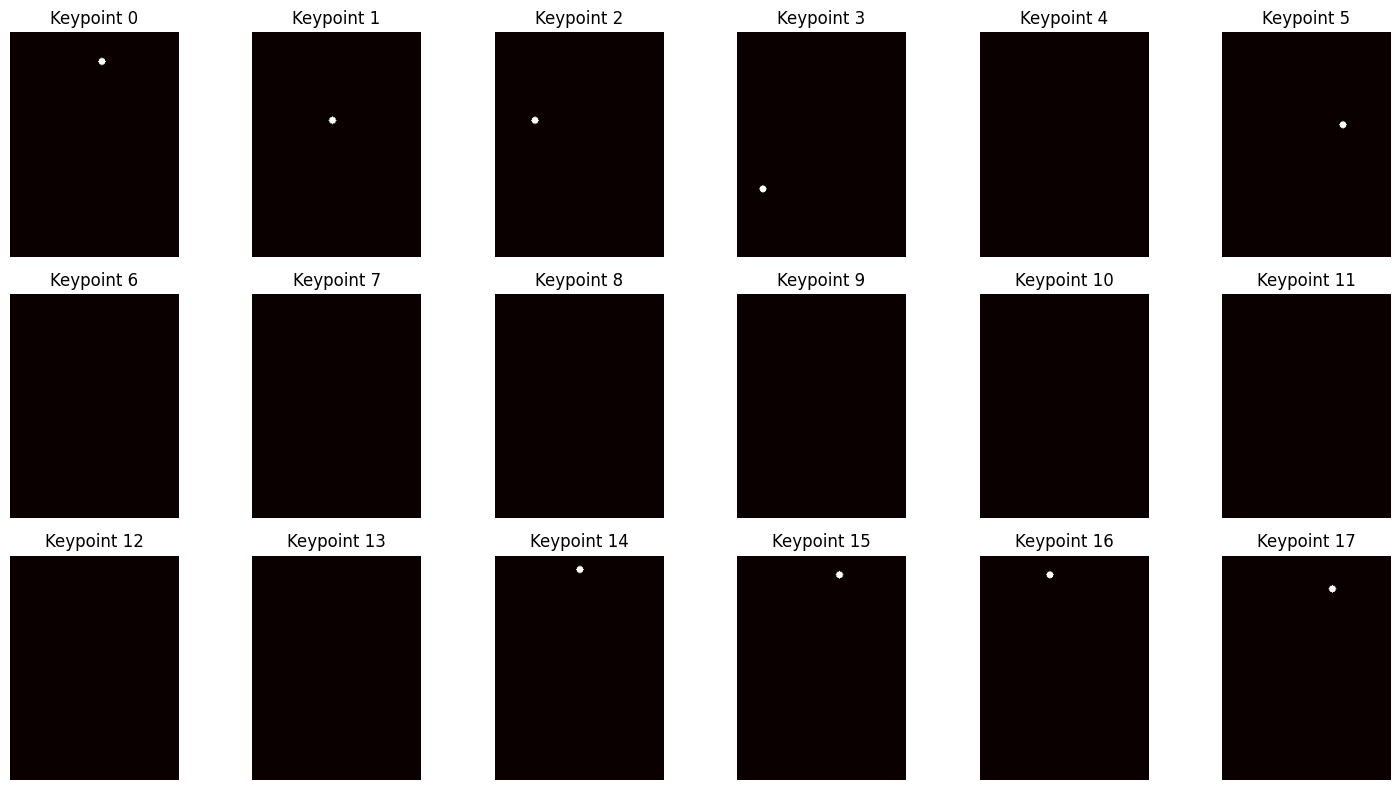

Warping clothing...
⚠️ Warning: Not enough valid keypoints, fallback used.
Generating try-on...
Postprocessing...
Try-on result saved as tryon_result_final.jpg!


In [150]:
# --- Full Virtual Try-On Pipeline (Pose-aware) ---

import os
import cv2
import numpy as np
import torch
from torchvision import transforms
from collections import OrderedDict

# from modnet import MODNet
# from pose_estimation import load_pose_model, extract_keypoints
# from thinplate.numpy import TPS, tps_theta_from_points, tps_grid
# from networks import UnetGenerator

# --- Load images
def load_images(person_path, clothing_path):
    if not os.path.exists(person_path) or not os.path.exists(clothing_path):
        raise FileNotFoundError("One or both image paths are invalid.")
    person_img = cv2.imread(person_path)
    clothing_img = cv2.imread(clothing_path)
    if person_img is None or clothing_img is None:
        raise ValueError("Failed to load one or both images.")
    return person_img, clothing_img

# --- Load cloth mask
def load_cloth_mask(cloth_mask_path):
    mask = cv2.imread(cloth_mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (192, 256))
    mask = mask / 255.0  # Normalize [0,1]
    return mask

# --- Preprocessing
def preprocess(person_img, segmentation_model, pose_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_img_normalized = person_img_resized / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    person_tensor = transform(person_img_normalized).unsqueeze(0).float()

    segmentation_mask = segmentation_model(person_tensor, inference=True)
    if segmentation_mask is None:
        raise ValueError("Segmentation model failed to produce mask.")

    keypoints = extract_keypoints(person_img_resized, pose_model)
    if not keypoints or len(keypoints) == 0:
        raise ValueError("Pose model failed to extract keypoints.")

    pose_map = generate_pose_map(keypoints, size=(256,192))  # <<< ✨ ADD this

    return segmentation_mask, keypoints, pose_map


# --- Create Pose Map (NEW for Phase 1)
def create_pose_map(keypoints, height=256, width=192, num_points=18, radius=5):
    pose_map = np.zeros((num_points, height, width), dtype=np.float32)
    for i, keypoint in enumerate(keypoints):
        if keypoint[0] > 0 and keypoint[1] > 0:
            x = int(keypoint[0] * width)
            y = int(keypoint[1] * height)
            cv2.circle(pose_map[i], (x, y), radius, 1.0, thickness=-1)
    return torch.tensor(pose_map)

def generate_pose_map(keypoints, size=(256,192), radius=4):
    """
    Generate 18-channel heatmaps for keypoints.
    """
    pose_map = np.zeros((18, size[0], size[1]), dtype=np.float32)

    for idx, (x, y) in enumerate(keypoints):
        if x == 0 and y == 0:
            continue
        x = int(x * size[1])
        y = int(y * size[0])
        cv2.circle(pose_map[idx], (x, y), radius, 1.0, thickness=-1)

    return torch.from_numpy(pose_map)


import matplotlib.pyplot as plt

def visualize_pose_maps(pose_maps):
    """
    Visualize the 18 pose maps (for COCO model).
    pose_maps: Tensor of shape (18, H, W)
    """
    pose_maps = pose_maps.detach().cpu().numpy()
    fig, axs = plt.subplots(3, 6, figsize=(15, 8))
    axs = axs.flatten()

    for i in range(18):
        axs[i].imshow(pose_maps[i], cmap='hot')
        axs[i].set_title(f"Keypoint {i}")
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()


# --- TPS Warp
def warp_clothing(clothing_img, keypoints_target, keypoints_cloth):
    clothing_img_resized = cv2.resize(clothing_img, (192, 256))
    height, width = clothing_img_resized.shape[:2]
    source_points = np.array(keypoints_cloth) * np.array([width, height])
    target_points = np.array(keypoints_target) * np.array([width, height])

    source_points = np.array([p for p in source_points if p[0] != 0 and p[1] != 0])
    target_points = np.array([p for p in target_points if p[0] != 0 and p[1] != 0])

    if len(source_points) < 6 or len(target_points) < 6:
        print("\u26a0\ufe0f Warning: Not enough valid keypoints, fallback used.")
        source_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]
        target_points = np.array([[0,0], [0,1], [1,0], [1,1], [0.5,0], [0.5,1]]) * [width, height]

    theta = tps_theta_from_points(target_points, source_points)
    grid = tps_grid(theta, target_points, (256, 192))
    map_x = (grid[..., 0] * width).astype(np.float32)
    map_y = (grid[..., 1] * height).astype(np.float32)

    warped = cv2.remap(clothing_img_resized, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)

    if warped.ndim == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 1:
        warped = cv2.cvtColor(warped, cv2.COLOR_GRAY2RGB)
    elif warped.shape[2] == 2:
        warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    return warped

# --- Generate Try-On
def generate_tryon(person_img, warped_clothing, cloth_mask, pose_map, generator_model):
    person_img_resized = cv2.resize(person_img, (192, 256))
    person_rgb = cv2.cvtColor(person_img_resized, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped_clothing, cv2.COLOR_BGR2RGB)

    transform = transforms.ToTensor()
    person_tensor = transform(person_rgb)
    clothing_tensor = transform(warped_rgb)
    mask_tensor = torch.tensor(cloth_mask).unsqueeze(0).float()

    person_masked = person_tensor * (1 - mask_tensor)
    cloth_masked = clothing_tensor * mask_tensor

    final_input = torch.cat([person_masked + cloth_masked, pose_map], dim=0).unsqueeze(0)  # (1, 21, 256, 192)

    output = generator_model(final_input)

    if output is None:
        raise ValueError("Generator model failed to produce output.")
    return output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()


# --- Postprocess
def postprocess(tryon_output):
    tryon_output = (tryon_output + 1) / 2
    tryon_output = np.clip(tryon_output, 0, 1)
    tryon_output = (tryon_output * 255).astype(np.uint8)
    tryon_output = cv2.medianBlur(tryon_output, 3)
    tryon_output = cv2.convertScaleAbs(tryon_output, alpha=1.05, beta=5)
    return tryon_output

# --- Full Pipeline
def virtual_tryon_pipeline(person_path, clothing_path, cloth_mask_path):
    try:
        print("Loading models...")
        segmentation_model = MODNet(backbone_pretrained=False)
        checkpoint = torch.load('/content/MODNet/pretrained/modnet_photographic_portrait_matting.ckpt', map_location='cpu')
        if 'state_dict' in checkpoint:
            checkpoint = checkpoint['state_dict']
        new_state_dict = OrderedDict()
        for k, v in checkpoint.items():
            if k.startswith('module.'):
                new_state_dict[k[7:]] = v
            else:
                new_state_dict[k] = v
        segmentation_model.load_state_dict(new_state_dict)

        pose_model = load_pose_model()
        generator_model = UnetGenerator(input_nc=21, output_nc=3, num_downs=7)  # Updated
        generator_model.eval()

        print("Loading images...")
        person_img, clothing_img = load_images(person_path, clothing_path)
        cloth_mask = load_cloth_mask(cloth_mask_path)

        print("Preprocessing...")
        segmentation_mask, keypoints_target, pose_map = preprocess(person_img, segmentation_model, pose_model)
        keypoints_cloth = extract_keypoints(cv2.resize(clothing_img, (192, 256)), pose_model)

        visualize_pose_maps(pose_map)

        print("Warping clothing...")
        warped_clothing = warp_clothing(clothing_img, keypoints_target, keypoints_cloth)

        print("Generating try-on...")
        tryon_output = generate_tryon(person_img, warped_clothing, cloth_mask, pose_map, generator_model)


        print("Postprocessing...")
        final_output = postprocess(tryon_output)

        return final_output

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# --- Example usage
if __name__ == "__main__":
    person_path = 'datasets/viton_hd/train/image/00001_00.jpg'
    clothing_path = 'datasets/viton_hd/train/cloth/00003_00.jpg'
    cloth_mask_path = 'datasets/viton_hd/train/cloth-mask/00003_00.jpg'

    result = virtual_tryon_pipeline(person_path, clothing_path, cloth_mask_path)
    if result is not None:
        cv2.imwrite('tryon_result_final.jpg', result)
        print("Try-on result saved as tryon_result_final.jpg!")


In [173]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# Assuming you have these utilities:
# from pose_estimation import extract_keypoints
# from pose_utils import generate_pose_map

class VITONPoseDataset(Dataset):
    def __init__(self, root_dir, pairs_txt, pose_model, transform=None, img_size=(256, 192)):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.img_size = img_size

        self.image_dir = os.path.join(root_dir, 'image')
        self.cloth_dir = os.path.join(root_dir, 'cloth')
        self.cloth_mask_dir = os.path.join(root_dir, 'cloth-mask')

        with open(pairs_txt, 'r') as f:
            self.pairs = [line.strip().split() for line in f.readlines()]

        self.pose_model = pose_model

        if self.transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
            ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        person_name, cloth_name = self.pairs[idx]

        # Load person image
        person_path = os.path.join(self.image_dir, person_name)
        person_img = cv2.imread(person_path)
        person_img = cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB)
        person_img = cv2.resize(person_img, self.img_size[::-1])

        # Load cloth image
        cloth_path = os.path.join(self.cloth_dir, cloth_name)
        cloth_img = cv2.imread(cloth_path)
        cloth_img = cv2.cvtColor(cloth_img, cv2.COLOR_BGR2RGB)
        cloth_img = cv2.resize(cloth_img, self.img_size[::-1])

        # Load cloth mask
        mask_path = os.path.join(self.cloth_mask_dir, cloth_name.replace('jpg', 'jpg'))
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.img_size[::-1]) / 255.0
        mask = np.expand_dims(mask, 0)  # (1, H, W)

        # Transform
        person_tensor = self.transform(person_img)
        cloth_tensor = self.transform(cloth_img)
        mask_tensor = torch.from_numpy(mask).float()

        # Extract pose keypoints
        keypoints = extract_keypoints(person_img, self.pose_model)
        pose_map = generate_pose_map(keypoints, size=self.img_size)

        return {
            'person': person_tensor,
            'cloth': cloth_tensor,
            'mask': mask_tensor,
            'pose_map': pose_map,
            'person_name': person_name,
            'cloth_name': cloth_name
        }


In [174]:
import cv2
import os

def load_pose_model():
    proto_file = 'openpose/models/pose/coco/pose_deploy_linevec.prototxt'
    weights_file = 'openpose/models/pose/coco/pose_iter_440000.caffemodel'

    if not os.path.exists(proto_file) or not os.path.exists(weights_file):
        raise FileNotFoundError("OpenPose COCO model files not found. Please check paths!")

    net = cv2.dnn.readNetFromCaffe(proto_file, weights_file)
    return net

def extract_keypoints(img, net, threshold=0.1):
    in_height = 256
    in_width = 192

    frame_width = img.shape[1]
    frame_height = img.shape[0]

    inp_blob = cv2.dnn.blobFromImage(img, 1.0 / 255, (in_width, in_height),
                                     (0, 0, 0), swapRB=False, crop=False)
    net.setInput(inp_blob)
    output = net.forward()

    H = output.shape[2]
    W = output.shape[3]
    keypoints = []

    for i in range(18):  # 18 keypoints for COCO
        prob_map = output[0, i, :, :]
        min_val, prob, min_loc, point = cv2.minMaxLoc(prob_map)

        x = (frame_width * point[0]) / W
        y = (frame_height * point[1]) / H

        if prob > threshold:
            keypoints.append((x / frame_width, y / frame_height))  # normalized
        else:
            keypoints.append((0, 0))

    return keypoints


pose_model = load_pose_model()  # <-- add this line BEFORE dataset creation

dataset = VITONPoseDataset(
    root_dir='/content/datasets/viton_hd/train',
    pairs_txt='/content/datasets/viton_hd/train_pairs.txt',
    pose_model=pose_model
)

sample = dataset[0]
print(sample['person'].shape, sample['cloth'].shape, sample['mask'].shape, sample['pose_map'].shape)




torch.Size([3, 256, 192]) torch.Size([3, 256, 192]) torch.Size([1, 256, 192]) torch.Size([18, 256, 192])


In [168]:
# # --- train.py ---toooooo lomba bhai this is too lomba

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import transforms
# from tqdm import tqdm

# # from dataset import VirtualTryOnDataset  # <-- the loader we made
# # from networks import UnetGenerator

# # --- Configurations
# EPOCHS = 10
# BATCH_SIZE = 32
# LR = 1e-4
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Prepare Dataset and DataLoader
# # dataset = VirtualTryOnDataset(
# #     root_dir='datasets/viton_hd/train',
# #     pairs_file='datasets/viton_hd/train_pairs.txt'
# # )
# data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

# # --- Model
# model = UnetGenerator(input_nc=21, output_nc=3, num_downs=7)
# model = model.to(DEVICE)
# model.train()

# # --- Loss and Optimizer
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))

# # --- Training Loop
# for epoch in range(EPOCHS):
#     epoch_loss = 0.0
#     loop = tqdm(data_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
#     for batch in loop:
#         person = batch['person'].to(DEVICE, non_blocking=True)
#         cloth = batch['cloth'].to(DEVICE, non_blocking=True)
#         mask = batch['mask'].to(DEVICE, non_blocking=True)
#         pose_map = batch['pose_map'].to(DEVICE, non_blocking=True)

#         # Prepare input
#         masked_person = person * (1 - mask)
#         masked_cloth = cloth * mask
#         input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)  # (B, 21, 256, 192)

#         # Forward
#         output = model(input_tensor)
#         output = torch.nn.functional.interpolate(output, size=(256, 192), mode='bilinear', align_corners=True)
#         loss = criterion(output, person)

#         # Backward
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()
#         loop.set_postfix(loss=loss.item())

#     print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {epoch_loss/len(data_loader):.4f}")

# # --- Save model
# torch.save(model.state_dict(), 'virtual_tryon_phase1.pth')
# print("Model saved as 'virtual_tryon_phase1.pth'!")


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


KeyboardInterrupt: 

In [169]:
# # --- train.py ---

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, Subset
# from torchvision import transforms
# from tqdm import tqdm

# # from dataset import VirtualTryOnDataset  # <-- the loader we made
# # from networks import UnetGenerator

# # --- Configurations
# EPOCHS = 10
# BATCH_SIZE = 32  # Increased batch size
# LR = 1e-4
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Prepare Dataset and DataLoader
# # dataset = VirtualTryOnDataset(
# #     root_dir='datasets/viton_hd/train',
# #     pairs_file='datasets/viton_hd/train_pairs.txt'
# # )

# # --- Reduce dataset size for faster training
# subset_indices = list(range(min(500, len(dataset))))
# dataset = Subset(dataset, subset_indices)

# # --- DataLoader
# data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# # --- Model
# model = UnetGenerator(input_nc=21, output_nc=3, num_downs=7)
# model = model.to(DEVICE)
# model.train()

# # --- Loss and Optimizer
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))

# # --- Training Loop
# for epoch in range(EPOCHS):
#     epoch_loss = 0.0
#     loop = tqdm(data_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
#     for batch in loop:
#         person = batch['person'].to(DEVICE, non_blocking=True)
#         cloth = batch['cloth'].to(DEVICE, non_blocking=True)
#         mask = batch['mask'].to(DEVICE, non_blocking=True)
#         pose_map = batch['pose_map'].to(DEVICE, non_blocking=True)

#         # Prepare input
#         masked_person = person * (1 - mask)
#         masked_cloth = cloth * mask
#         input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)

#         # Forward
#         output = model(input_tensor)
#         output = torch.nn.functional.interpolate(output, size=(256, 192), mode='bilinear', align_corners=True)
#         loss = criterion(output, person)

#         # Backward
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()
#         loop.set_postfix(loss=loss.item())

#     print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {epoch_loss/len(data_loader):.4f}")

# # --- Save model
# torch.save(model.state_dict(), 'virtual_tryon_phase1.pth')
# print("Model saved as 'virtual_tryon_phase1.pth'!")


KeyboardInterrupt: 

In [176]:
# --- train.py (FINAL CLEAN) ---

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from tqdm import tqdm

# from dataset import VITONPoseDataset
# from networks import UnetGenerator
# from pose_estimation import load_pose_model

# --- Configurations
EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (192, 128)  # <<< BIGGER input

# --- Load Pose Model
pose_model = load_pose_model()

# --- Prepare Dataset and DataLoader
dataset = VITONPoseDataset(
    root_dir='datasets/viton_hd/train',
    pairs_txt='datasets/viton_hd/train_pairs.txt',
    pose_model=pose_model,
    img_size=IMG_SIZE
)

subset_indices = list(range(min(500, len(dataset))))
dataset = Subset(dataset, subset_indices)

# --- DataLoader
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# --- Model
model = UnetGenerator(input_nc=21, output_nc=3, num_downs=6)  # <<< 6 downs only
model = model.to(DEVICE)
model.train()

# --- Loss and Optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))
scaler = torch.amp.GradScaler()  # fixed

# --- Training Loop
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    loop = tqdm(data_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
    for batch in loop:
        person = batch['person'].to(DEVICE, non_blocking=True)
        cloth = batch['cloth'].to(DEVICE, non_blocking=True)
        mask = batch['mask'].to(DEVICE, non_blocking=True)
        pose_map = batch['pose_map'].to(DEVICE, non_blocking=True)

        masked_person = person * (1 - mask)
        masked_cloth = cloth * mask
        input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)

        with torch.amp.autocast(device_type='cuda'):
            output = model(input_tensor)
            loss = criterion(output, person)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {epoch_loss/len(data_loader):.4f}")

# --- Save model
torch.save(model.state_dict(), 'virtual_tryon_phase1.pth')
print("Model saved as 'virtual_tryon_phase1.pth'!")


Epoch [1/10], Average Loss: 0.3914


Epoch [2/10], Average Loss: 0.2584


Epoch [3/10], Average Loss: 0.2316


Epoch [4/10], Average Loss: 0.2102


Epoch [5/10], Average Loss: 0.1899


Epoch [6/10], Average Loss: 0.1774


Epoch [7/10], Average Loss: 0.1682


Epoch [8/10], Average Loss: 0.1626


Epoch [9/10], Average Loss: 0.1557


Epoch [10/10], Average Loss: 0.1489
Model saved as 'virtual_tryon_phase1.pth'!


In [177]:
# --- evaluate.py ---

import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# --- Load model
model = UnetGenerator(input_nc=21, output_nc=3, num_downs=6)
model.load_state_dict(torch.load('virtual_tryon_phase1.pth'))
model = model.to(DEVICE)
model.eval()

# --- Inference (on few samples)
num_samples = 8
examples = next(iter(DataLoader(dataset, batch_size=num_samples, shuffle=True)))

with torch.no_grad():
    person = examples['person'].to(DEVICE)
    cloth = examples['cloth'].to(DEVICE)
    mask = examples['mask'].to(DEVICE)
    pose_map = examples['pose_map'].to(DEVICE)

    masked_person = person * (1 - mask)
    masked_cloth = cloth * mask
    input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)

    with torch.amp.autocast(device_type='cuda'):
        outputs = model(input_tensor)

# --- Visualize
fig, axs = plt.subplots(3, num_samples, figsize=(20, 8))

for i in range(num_samples):
    axs[0, i].imshow(person[i].cpu().permute(1,2,0)*0.5 + 0.5)
    axs[0, i].set_title('Person')
    axs[0, i].axis('off')

    axs[1, i].imshow(cloth[i].cpu().permute(1,2,0)*0.5 + 0.5)
    axs[1, i].set_title('Cloth')
    axs[1, i].axis('off')

    axs[2, i].imshow(outputs[i].cpu().permute(1,2,0)*0.5 + 0.5)
    axs[2, i].set_title('Try-On')
    axs[2, i].axis('off')

plt.tight_layout()
plt.show()

# --- Quick metric (L1)
reconstruction_loss = torch.nn.functional.l1_loss(outputs, person)
print(f"Reconstruction L1 Loss: {reconstruction_loss.item():.4f}")


ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 2000x800 with 24 Axes>

Reconstruction L1 Loss: 0.1597


In [180]:
!pip install torchmetrics
!pip install pytorch-fid


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [181]:
import torchmetrics
import numpy as np

# --- Create metric calculators
ssim_metric = torchmetrics.StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
psnr_metric = torchmetrics.PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)

# FID setup (optional phase 2)
from pytorch_fid import fid_score

def tensor_to_img(t):
    """Convert tensor (B,C,H,W) -> (B,H,W,C) numpy [0,255] uint8"""
    t = (t * 0.5) + 0.5
    t = (t * 255).clamp(0, 255).byte()
    return t.permute(0,2,3,1).cpu().numpy()

# --- During Inference Loop
model.eval()
all_outputs = []
all_targets = []

for batch in data_loader:
    person = batch['person'].to(DEVICE)
    cloth = batch['cloth'].to(DEVICE)
    mask = batch['mask'].to(DEVICE)
    pose_map = batch['pose_map'].to(DEVICE)

    masked_person = person * (1 - mask)
    masked_cloth = cloth * mask
    input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)

    with torch.amp.autocast(device_type='cuda'):
        output = model(input_tensor)

    # Resize output to match person
    output = torch.nn.functional.interpolate(output, size=person.shape[2:], mode='bilinear', align_corners=True)

    # --- Calculate SSIM and PSNR
    ssim = ssim_metric(output, person)
    psnr = psnr_metric(output, person)

    print(f"Batch SSIM: {ssim.item():.4f}, Batch PSNR: {psnr.item():.2f} dB")

    # Collect for FID
    all_outputs.append(output)
    all_targets.append(person)

    break  # for now one batch, remove later



/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(


Batch SSIM: 0.5527, Batch PSNR: 11.04 dB


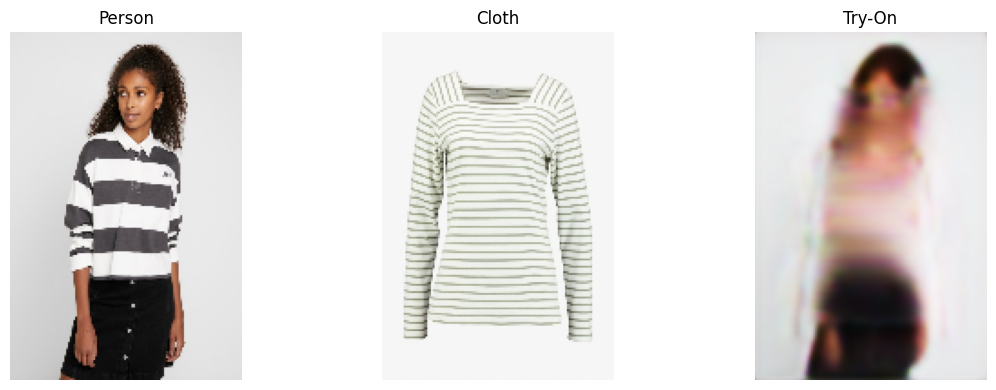

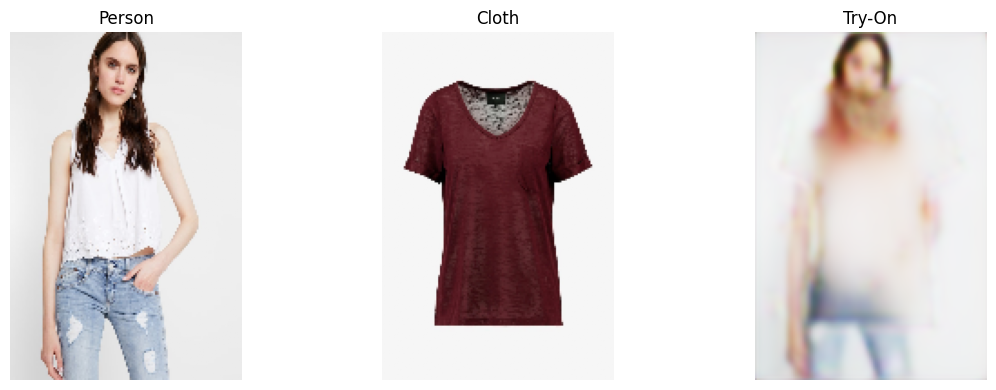

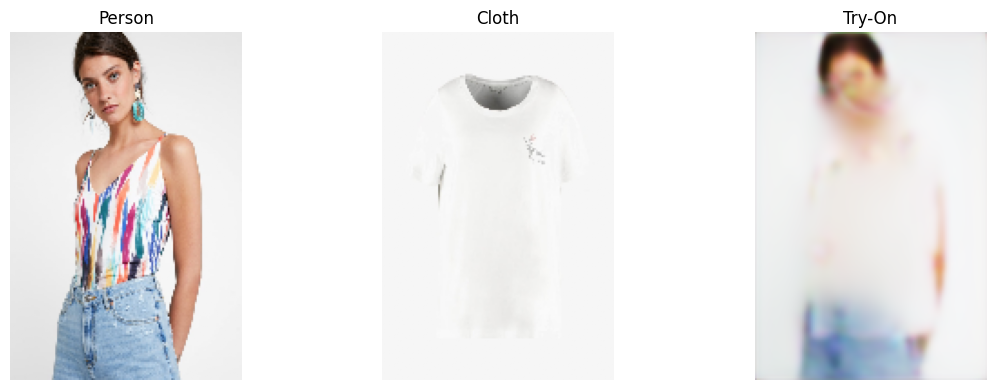

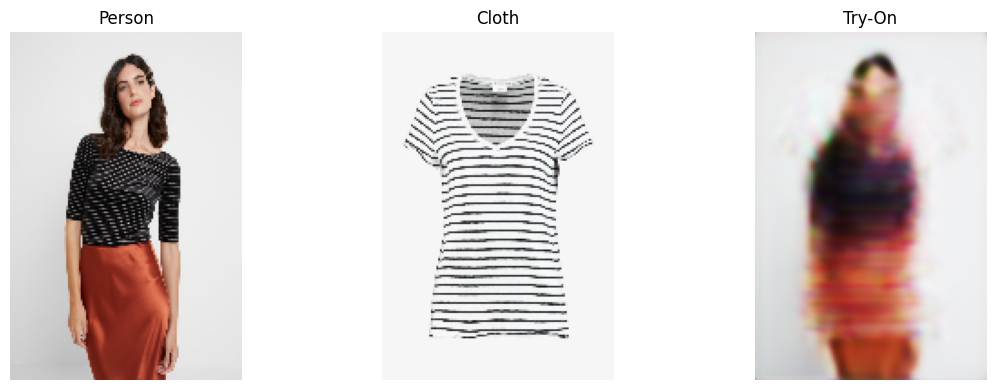

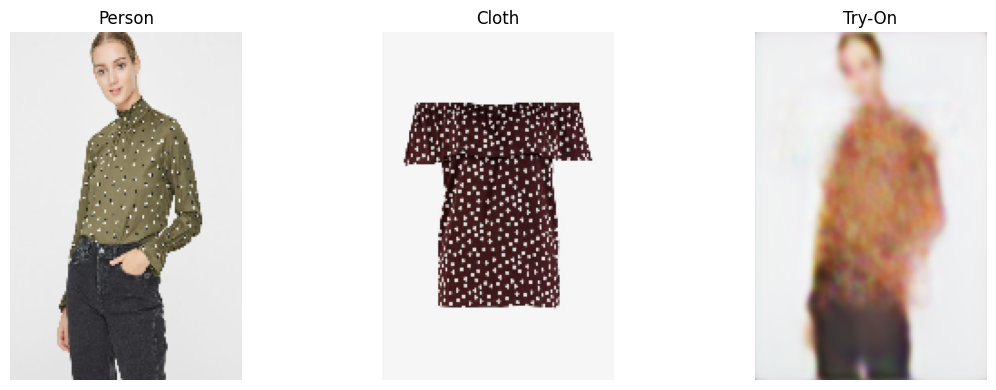

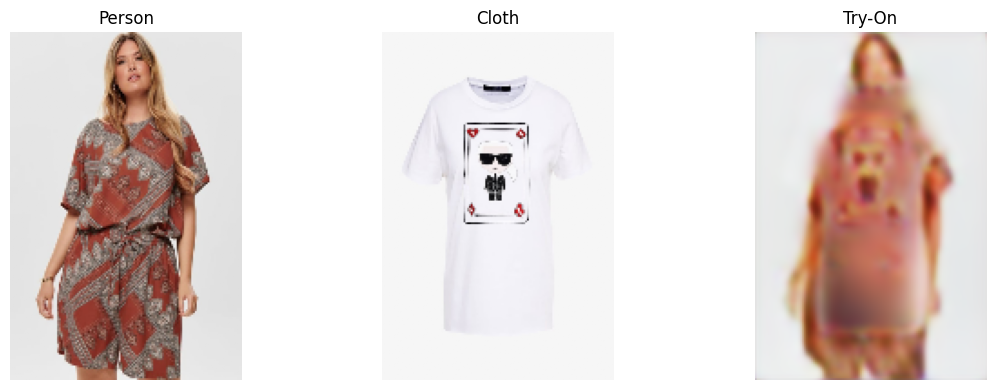

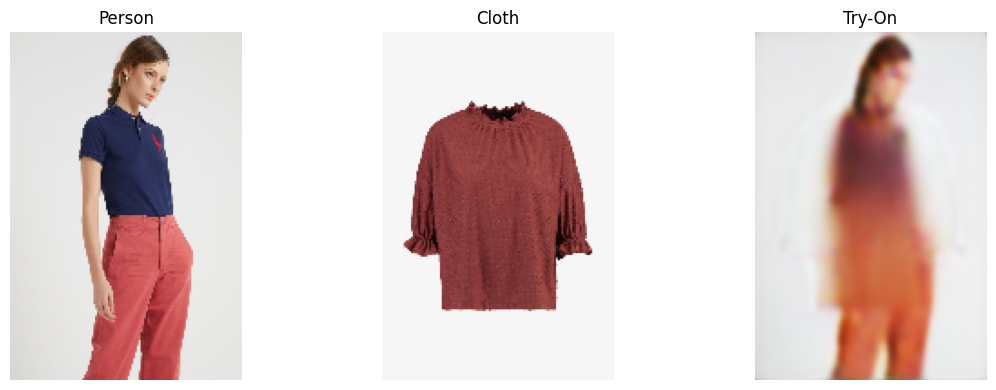

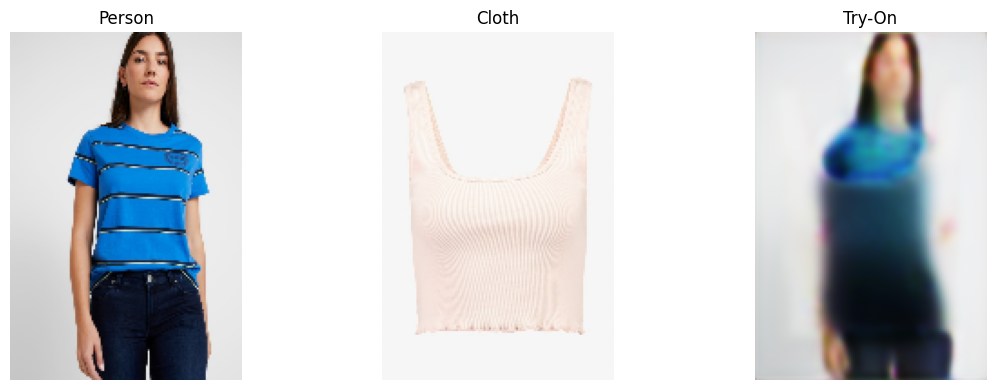

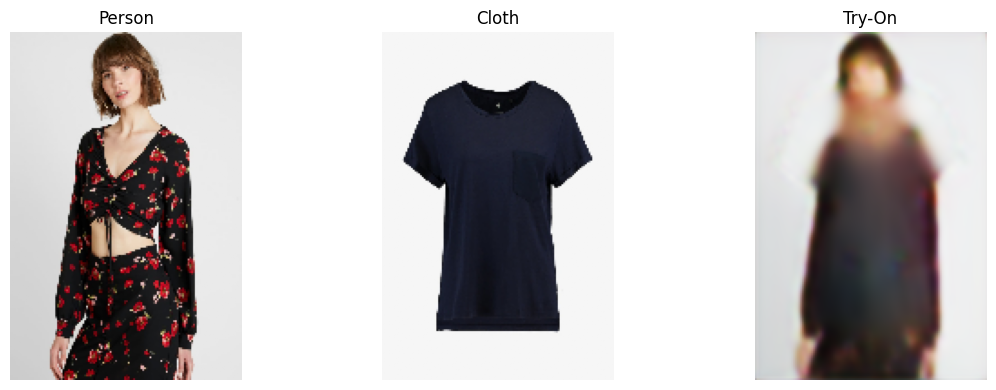

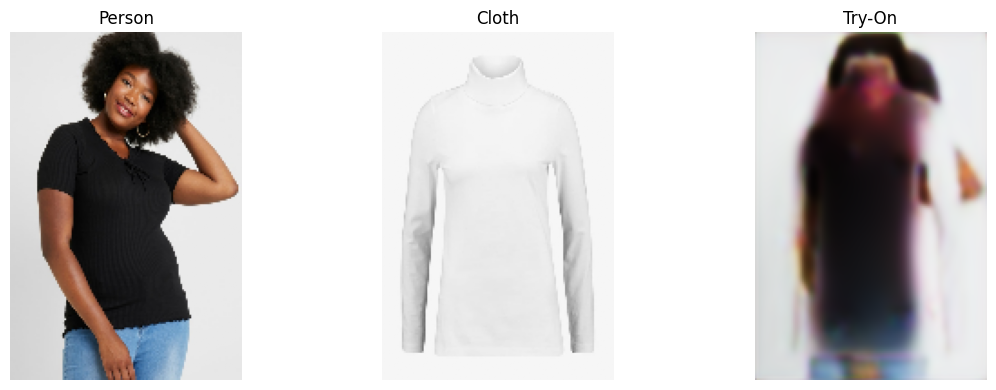

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision

# --- Helper Functions

def tensor_to_image(tensor):
    """Convert a normalized torch tensor to numpy image (H, W, C) for plotting."""
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu()
        if tensor.ndim == 3 and tensor.shape[0] == 3:  # (C,H,W)
            tensor = tensor.permute(1, 2, 0)  # -> (H,W,C)
        img = tensor.numpy()
        img = (img * 0.5) + 0.5  # [-1,1] -> [0,1]
        img = img.clip(0, 1)
        return img
    else:
        raise TypeError("Expected torch.Tensor, got {}".format(type(tensor)))

def plot_sample(person, cloth, tryon_output, titles=["Person", "Cloth", "Try-On"]):
    """Plot person image, cloth image, and try-on result side by side."""
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    imgs = [person, cloth, tryon_output]

    for ax, img, title in zip(axs, imgs, titles):
        ax.imshow(tensor_to_image(img))
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- Evaluation / Inference Example

model.eval()
with torch.no_grad():
    for batch in data_loader:
        person = batch['person'].to(DEVICE)
        cloth = batch['cloth'].to(DEVICE)
        mask = batch['mask'].to(DEVICE)
        pose_map = batch['pose_map'].to(DEVICE)

        masked_person = person * (1 - mask)
        masked_cloth = cloth * mask
        input_tensor = torch.cat([masked_person + masked_cloth, pose_map], dim=1)

        with torch.amp.autocast(device_type='cuda'):
            output = model(input_tensor)

                # Pick the first sample from the batch
        p = person[0].float()
        c = cloth[0].float()
        o = output[0].float()

        # --- Plot nicely
        plot_sample(p, c, o)

